## My own way to align subs to reference
(reorder and flip-sign if necessary)

--> found out that the brainspace built in procrust alignment does work, was just reading the wrong part out of the fitted GM
[`gm.aligned_` vs. `gm.gradients_`]
* but with kernel=None filtering is still necessary!


In [1]:
from utils_02 import plot_GM123_from_sum_npfile, plot_from_nparray
import numpy as np
import nilearn.plotting as nplt
import nibabel as nib
import matplotlib.pyplot as plt
import os.path as op
from  nilearn.datasets import fetch_surf_fsaverage
from os import listdir
from nilearn import datasets


bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
grad_folder = 'derivatives/gradients'

# numpy files ref-aligned (kerne = 'normalized_angle',approach='le',alignment='procrust',ref=')
subList = [f[4:6] for f in listdir(op.join(bids_folder, grad_folder)) if f[0:4] == 'sub-' and len(f)==45]
subList_npFiles = [f for f in listdir(op.join(bids_folder, grad_folder)) if f[0:4] == 'sub-' and len(f)==45]

240208-14:50:43,770 nipype.utils WARNING:
	 A newer version (1.8.4) of nipy/nipype is available. You are using 1.8.3


In [2]:
# better version (from looking at first 5 subjects)
# put first version (inspired by copilot) in utils_02.py

from nilearn import datasets

def align_gradients_ROIdependant(gradients, reference): # this version does not bother about nan values
    gradients = np.array(gradients)
    reference_grad = np.array(reference)

    # get masks
    atlas = datasets.fetch_atlas_surf_destrieux()
    labeling = np.concatenate([atlas['map_left'], atlas['map_right']]) # table with regions and names: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2937159/

    motor_mask = np.isin(labeling, atlas.labels.index(b'G_precentral')) 
    occ_mask = np.isin(labeling, atlas.labels.index(b'Pole_occipital'))
    atlats_index_highOrder = [atlas.labels.index(b'S_temporal_sup'), atlas.labels.index(b'S_interm_prim-Jensen')] # temporal, TPJ
    atlats_index_lowOrder = [atlas.labels.index(b'G_precentral'), atlas.labels.index(b'Pole_occipital' )] # motor, visual
    highOrderRegions_mask = np.isin(labeling, atlats_index_highOrder)
    lowOrderRegions_mask = np.isin(labeling, atlats_index_lowOrder)

    difs = np.zeros(shape = (3,2))
    for grad_n in range(3):
        dif_forgrad1 = gradients[grad_n][highOrderRegions_mask].mean() - gradients[grad_n][lowOrderRegions_mask].mean()
        dif_forgrad2 = gradients[grad_n][motor_mask].mean() - gradients[grad_n][occ_mask].mean()
        difs[grad_n,:] = [np.abs(dif_forgrad1), np.abs(dif_forgrad2)]
    print(difs)
    max_difs_masks_indices = np.argmax(np.abs(difs), axis=0)
    print(max_difs_masks_indices) # should work from inspecting the difs * , max_difs

    # assign the missing gradient   
    all_numbers = set(range(3))
    missing_number = all_numbers - set(max_difs_masks_indices)
    max_difs_masks_indices = np.append(max_difs_masks_indices, missing_number.pop())
    print(max_difs_masks_indices)  

    max_difs_masks_indices = np.array(max_difs_masks_indices, dtype=int).flatten()
    # Reorder gradients based on the index of the reference gradient with the highest absolute dot product
    gradients = gradients[np.argsort(max_difs_masks_indices), :]
    dot_products = np.array([[np.nansum(g * r) for r in reference] for g in gradients]) # kind of np.dot, but ignoring nans
    
    print(dot_products)
    # Flip gradients where the dot product with the corresponding reference gradient is negative
    for i in range(np.shape(gradients)[0]):
        if dot_products[i,i] < 0:
            gradients[i] *= -1

    return gradients

In [4]:
# load in reference for the alignment
from utils_02 import get_reference_gradient

reference_grad = get_reference_gradient()

sub-01_ses-1_ref-p-align_fsav5_unfiltered.npy
[[6.87417141e-05 1.50173232e-04]
 [6.84672370e-05 1.64017544e-05]
 [8.86709975e-05 7.50125012e-05]]
[2 0]
[2 0 1]
[[-1.9409939  -0.17661545 -0.68467494]
 [ 8.72076459 -0.72609031 -1.51331051]
 [-3.18869137 12.9704823  -2.94096465]]


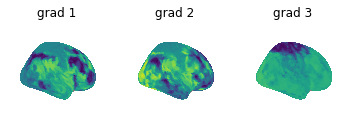

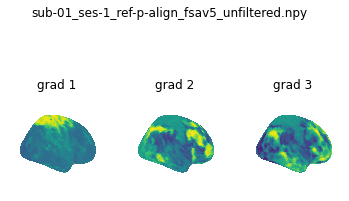

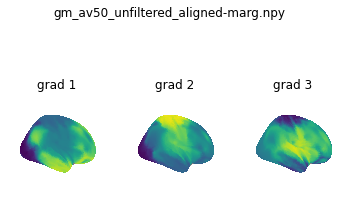

In [6]:
# aligment (plus loading in the subjetc gradients)
sub = 0
file = subList_npFiles[sub]
print(file)
gm = np.load(op.join(bids_folder,grad_folder,file))

grad = [None] * np.shape(gm)[1]
for i, g in enumerate(gm.T):
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
gradients = grad

grad_aligned = align_gradients_ROIdependant(gradients, reference_grad)   
plot_from_nparray(grad_aligned)
plot_GM123_from_sum_npfile(file=subList_npFiles[sub])
plot_GM123_from_sum_npfile()

### and now only save it, ultimately to ...fsnative.gii so that I can use it in the vis_nPRF with gradients beneath script 